In [7]:
#Inicialización: borra todo y carga librerías (se pueden instalar fácilmente si no las tienen):
# install.packages("libreríaquequiero")

#Borra consola, variables y funciones definidas en el entorno Global
rm(list = setdiff(ls(), lsf.str()));
rm(list=lsf.str());
cat("\014")

#librerías, temas
suppressMessages(library("crayon")); suppressMessages(library("ggplot2"));
suppressMessages(library("gridExtra"));suppressMessages(library("latex2exp"))
library(xtable)
library(IRdisplay)
library(repr)

#opciones de ploteo ggplot2
temajuan3 <- theme(
    legend.title = element_text(size = 14),
    panel.background = element_rect(fill = "gray93"),
    legend.box = "vertical",
    legend.direction = "vertical",
    legend.key.height = unit(0.1,"snpc"),
    legend.key.width  = unit(0.1,"snpc"),
    axis.line = element_line(size = 0.5, lineend = "square"),
    axis.ticks = element_line(size = 1, colour = "black"),
    panel.border = element_rect(size = 1, fill = NA ),
    axis.title = element_text(size = 32),
    axis.text.x  = element_text(size = 28),
    axis.text.y = element_text(size = 28),
    legend.background = element_blank(),
    legend.position = c(0.3,0.8),
    legend.key = element_blank(),
    legend.text = element_text(size = 20),
    plot.title = element_text(size = 24)
    )
source("/home/juan/Documentos/Rfunj/temajuan2.R")
fig <- function(width, heigth){
 options(repr.plot.width = width, repr.plot.height = heigth)
 }
setwd("/home/juan/Documentos/Docencia/fexpi/")
fig(20,12)


Attaching package: ‘IRdisplay’


The following object is masked from ‘package:xtable’:

    display




# Teorema del Límite Central


Este es uno de los teoremas más importantes en teoría de probabilidad.

 + Como toda la teoría, al principio no quiere decir mucho.
 
 + Al final, es un buen lente desde donde mirar las cosas.
 
 Lo vamos a enunciar, depués vemos cómo lo estuvimos usando todo el tiempo.

In [8]:
L

ERROR: Error in eval(expr, envir, enclos): objeto 'L' no encontrado


##### $f_X(x)$: Función densidad de probabilidad en R:
+ `x` es un vector con los valores de la variable aleatoria
+ `dnorm(x, mean = , sd = )` nos da los valores de la función densidad de probabilidad con $\mu = $ `mean` y $\sigma = $ `sd` 

In [9]:
x <- seq(-4,4,0.01) #variable
s <- 1 #desviación estándar
mi <-0 #media
fx <- dnorm(x = x, mean = 0, sd = s) #función densidad de probabilidad normal


In [10]:
y1 <- fx
yalpha <- (y1-min(y1))/ (max(y1)-min(y1))

seg <- c(-3,-2,-1,1,2,3)

gcanon <- ggplot() + 
  
  geom_segment(aes(x = x, xend = x, y = rep(0, length(x)), yend = y1, alpha = yalpha^1.75), colour = "DeepSkyblue4", lwd = 0.35,show.legend = F) +
  geom_line(aes(x = x, y = y1), size = 1.25, show.legend = F) + 
  geom_segment(aes(x = seg, xend = seg, y = rep(0, 6), yend = dnorm(x = seg))) + 
  ylab("f(x)") +
  xlab("x") +
  ggtitle("Función Densidad de Probabilidad - Distribución Normal") + 
  scale_y_continuous(breaks = seq(0, (max(y1)+0.1), 0.1),limits = c(0,max(y1)+0.025), expand=c(0,0)) + 
  scale_x_continuous(breaks = c(-3,-2,-1,0,1,2,3),
                     labels = c(expression(paste(mu,"-3",sigma)),
                                expression(paste(mu, "-2",sigma)),
                                expression(paste(mu, "- ",sigma)),
                                expression(paste(mu)),
                                expression(paste(mu, "+",sigma)),
                                expression(paste(mu, "+2",sigma)),
                                expression(paste(mu, "+3",sigma))),
                     limits = c(-4,4), expand=c(0,0))+
temajuan3 


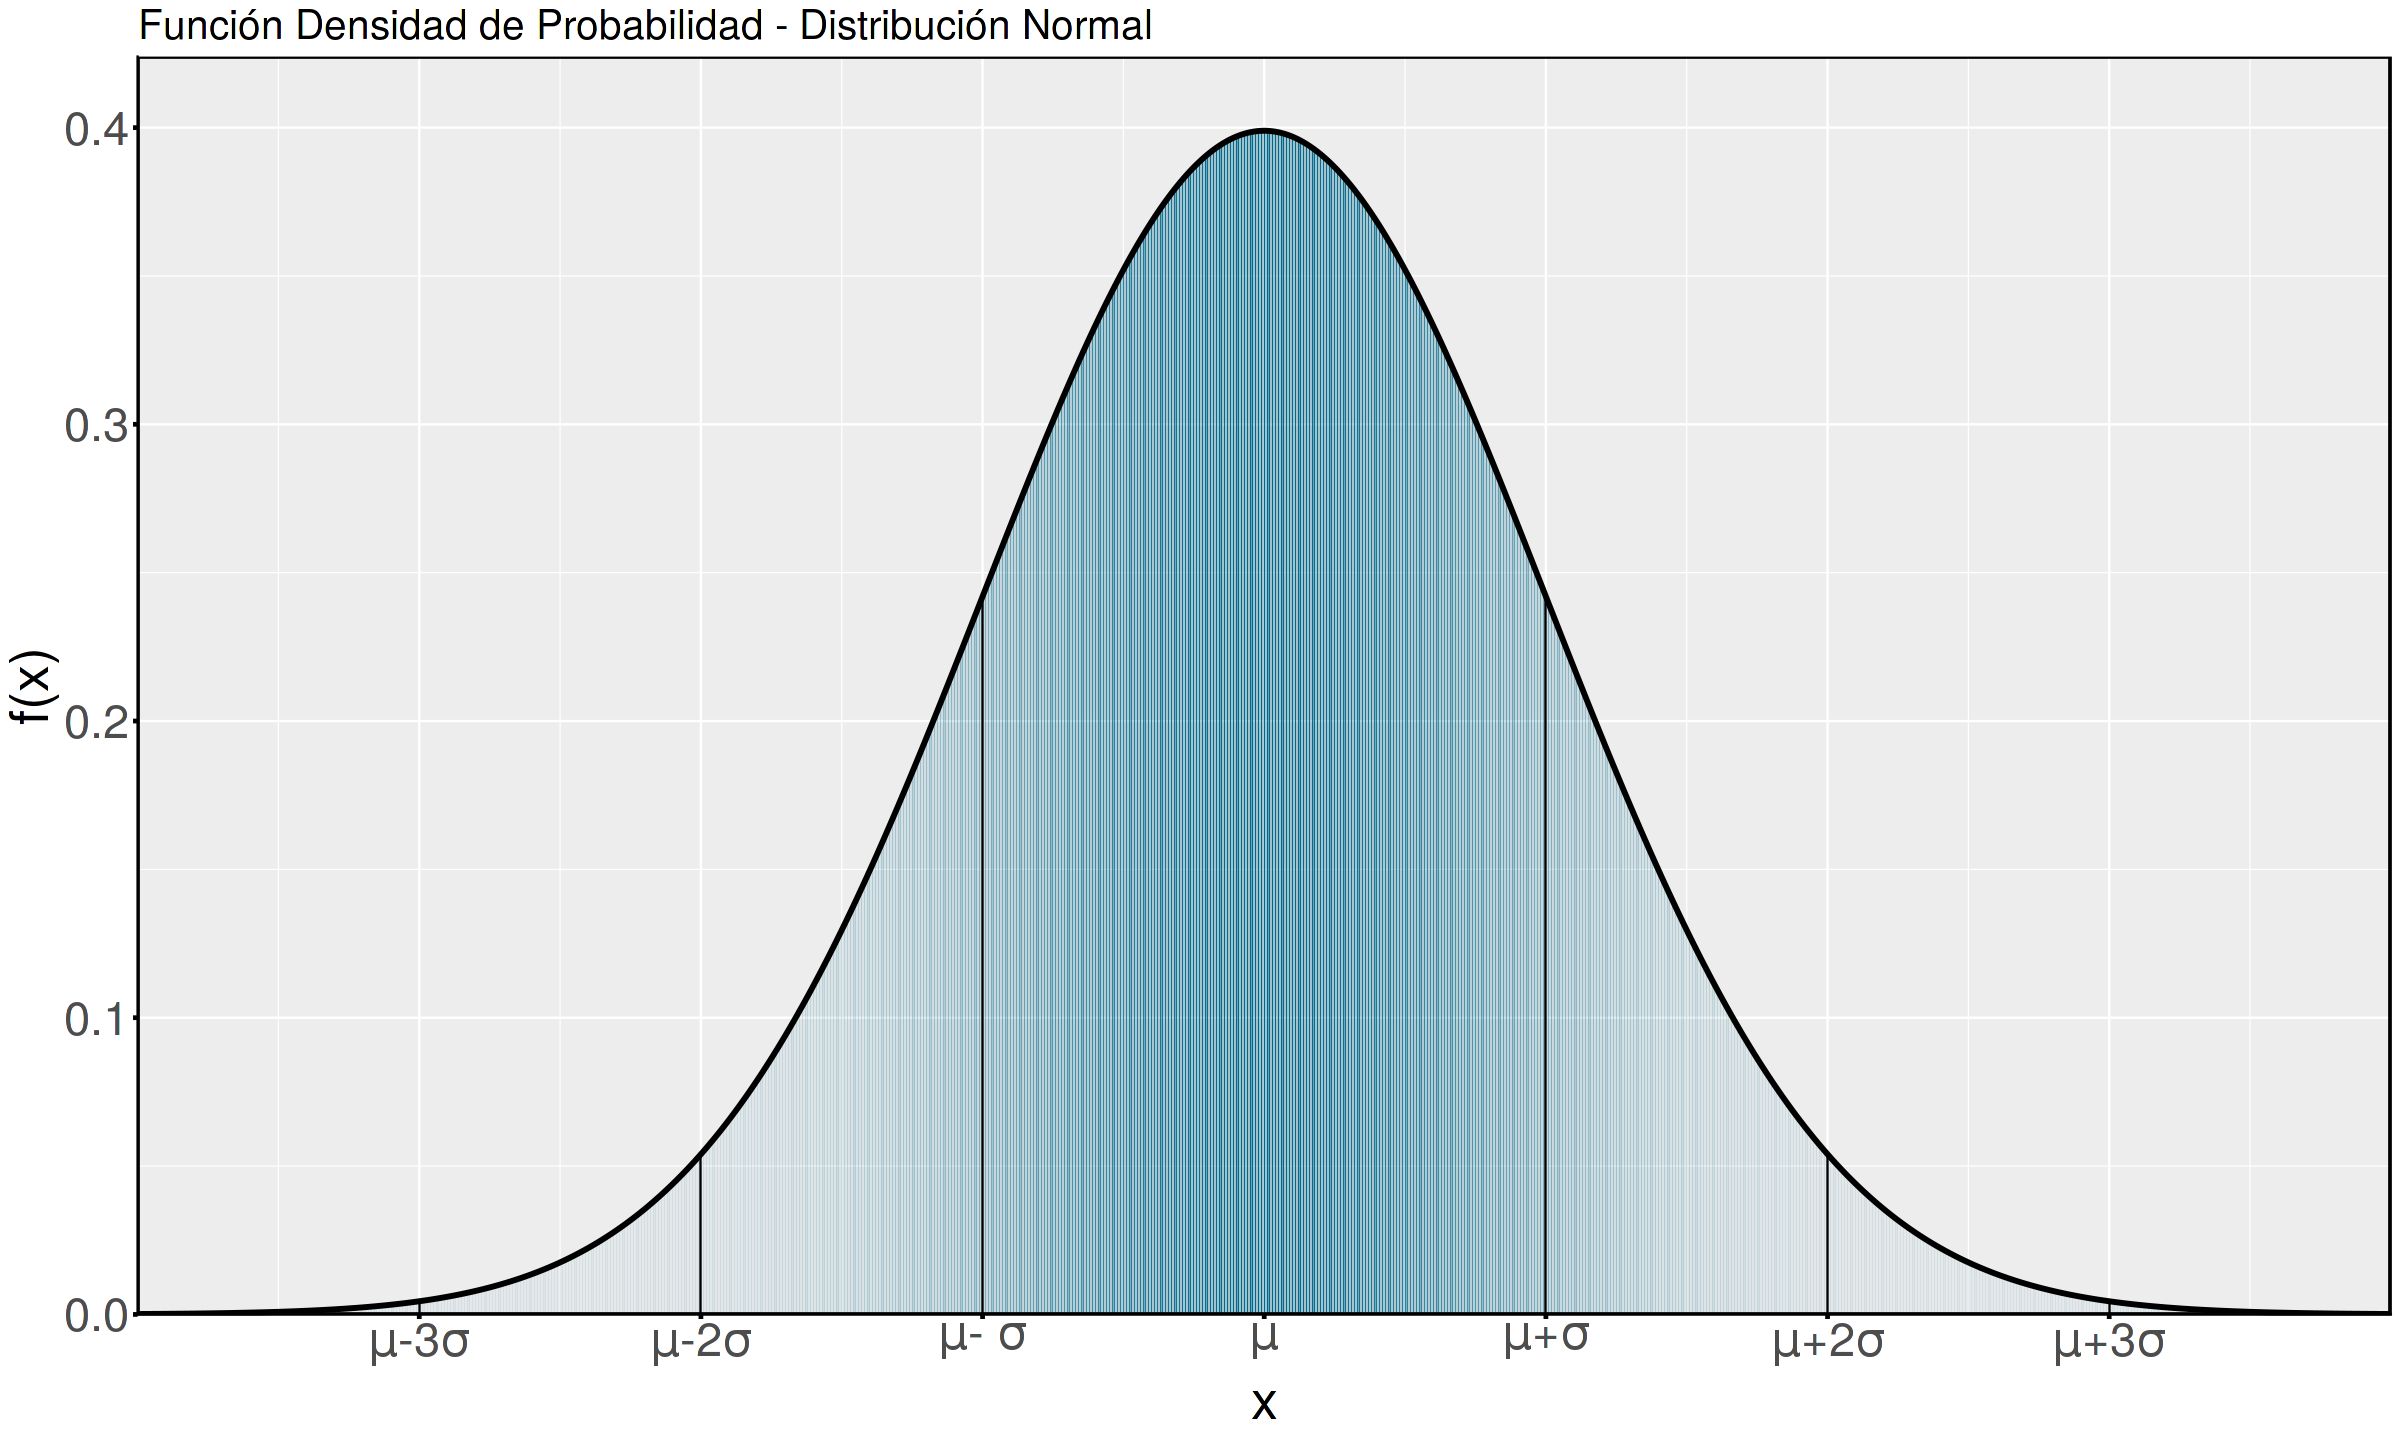

In [11]:
show(gcanon)

##### $F_X(x)$: Función de probabilidad Acumulada en R:
+ `q` es el vector de cuantiles (*quantiles*) con los valores de la variable aleatoria
+ `pnorm(q, mean = , sd = )` nos da los valores de la función densidad de probabilidad con $\mu = $ `mean` y $\sigma = $ `sd` 

In [12]:
Fx <- pnorm(q = x, mean = 0, sd = 1)

In [13]:
gFx <- ggplot() + 
  geom_line(aes(x = x, y = Fx), size = 1.25, show.legend = F) + 
  ylab("F(x)") +
  xlab("x") +
  ggtitle("Función Probabilidad Acumulada - Distribución Normal") + 
  scale_y_continuous(expand=c(0,0), limits = c(-0.01,1.01)) + 
  scale_x_continuous(breaks = c(-3,-2,-1,0,1,2,3),
                     labels = c(expression(paste(mu,"-3",sigma)),
                                expression(paste(mu, "-2",sigma)),
                                expression(paste(mu, "- ",sigma)),
                                expression(paste(mu)),
                                expression(paste(mu, "+",sigma)),
                                expression(paste(mu, "+2",sigma)),
                                expression(paste(mu, "+3",sigma))),
                     limits = c(-4,4), expand=c(0,0))+
temajuan3 

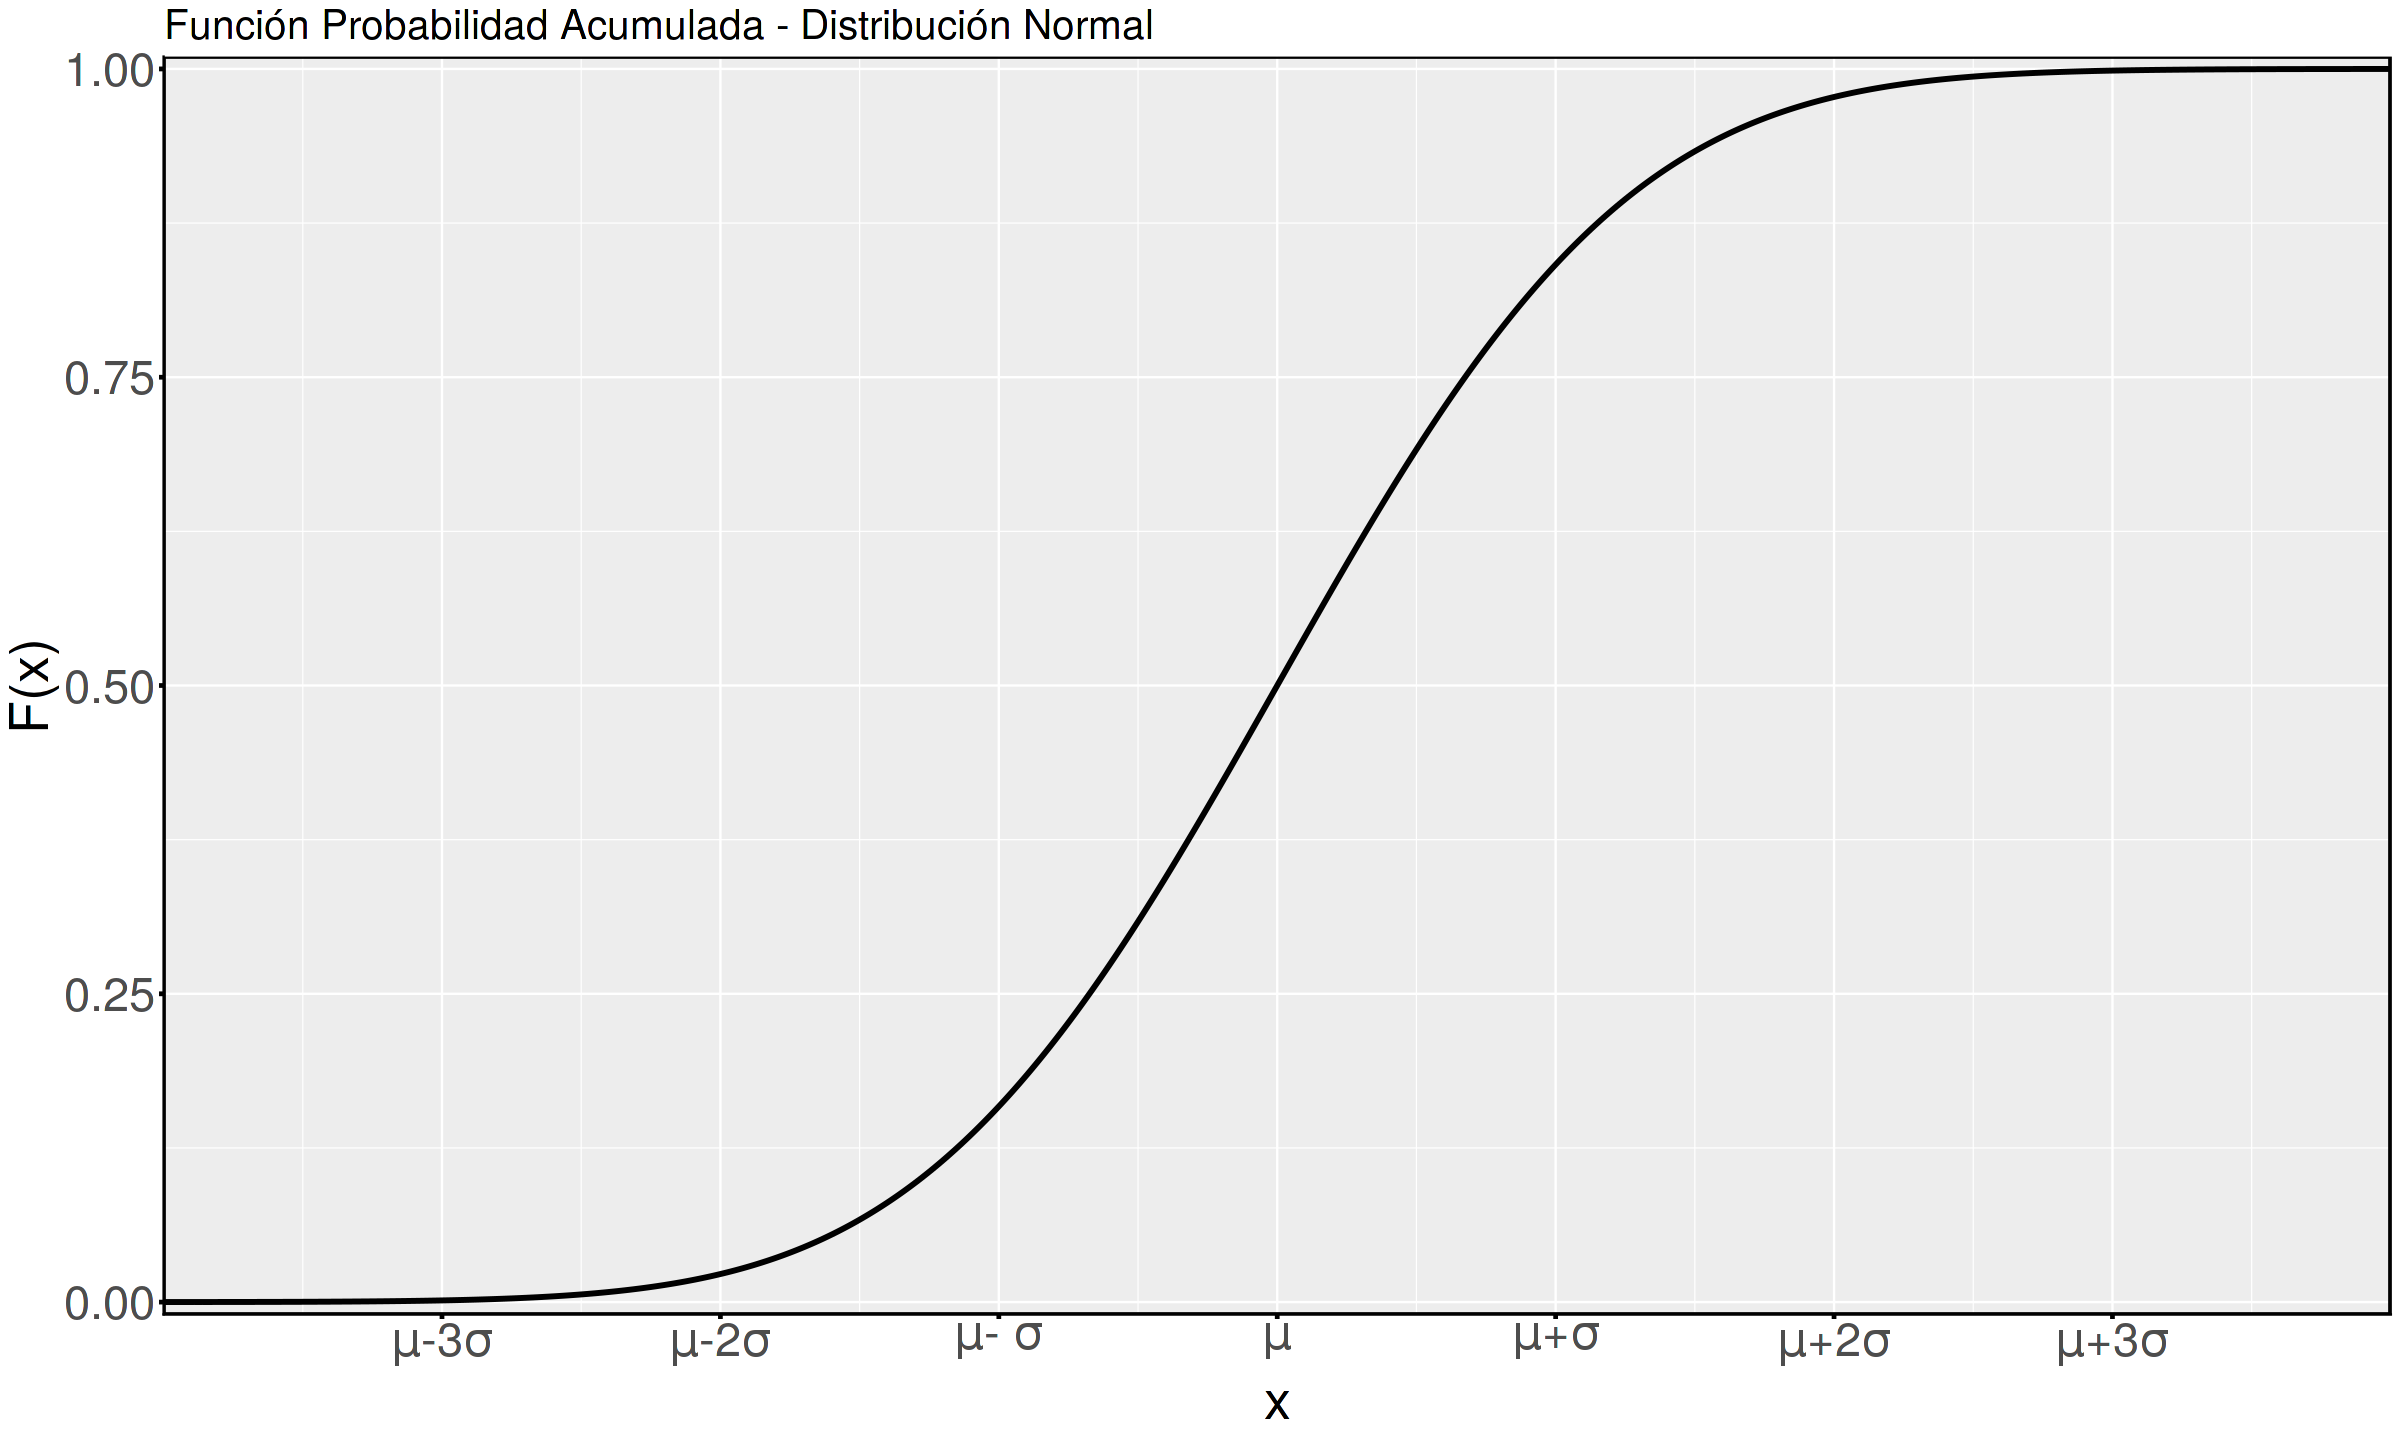

In [14]:
show(gFx)

También se pueden dibujar otras varias (ver apunte). No se vuelvan loques.

# *Pseudo Random Number Generators*
* Nos tiran números con la distribución que nos guste.
* Son números con poca estructura (no tienen correlación)
* Un generador de pseudo aleatorios es, matemáticamente, una máquina de ***sinsentidos***


<img src="https://media1.tenor.com/images/e557a85348a61e17d35d93d5a7b7bb9f/tenor.gif?itemid=15409398" width="800"/>

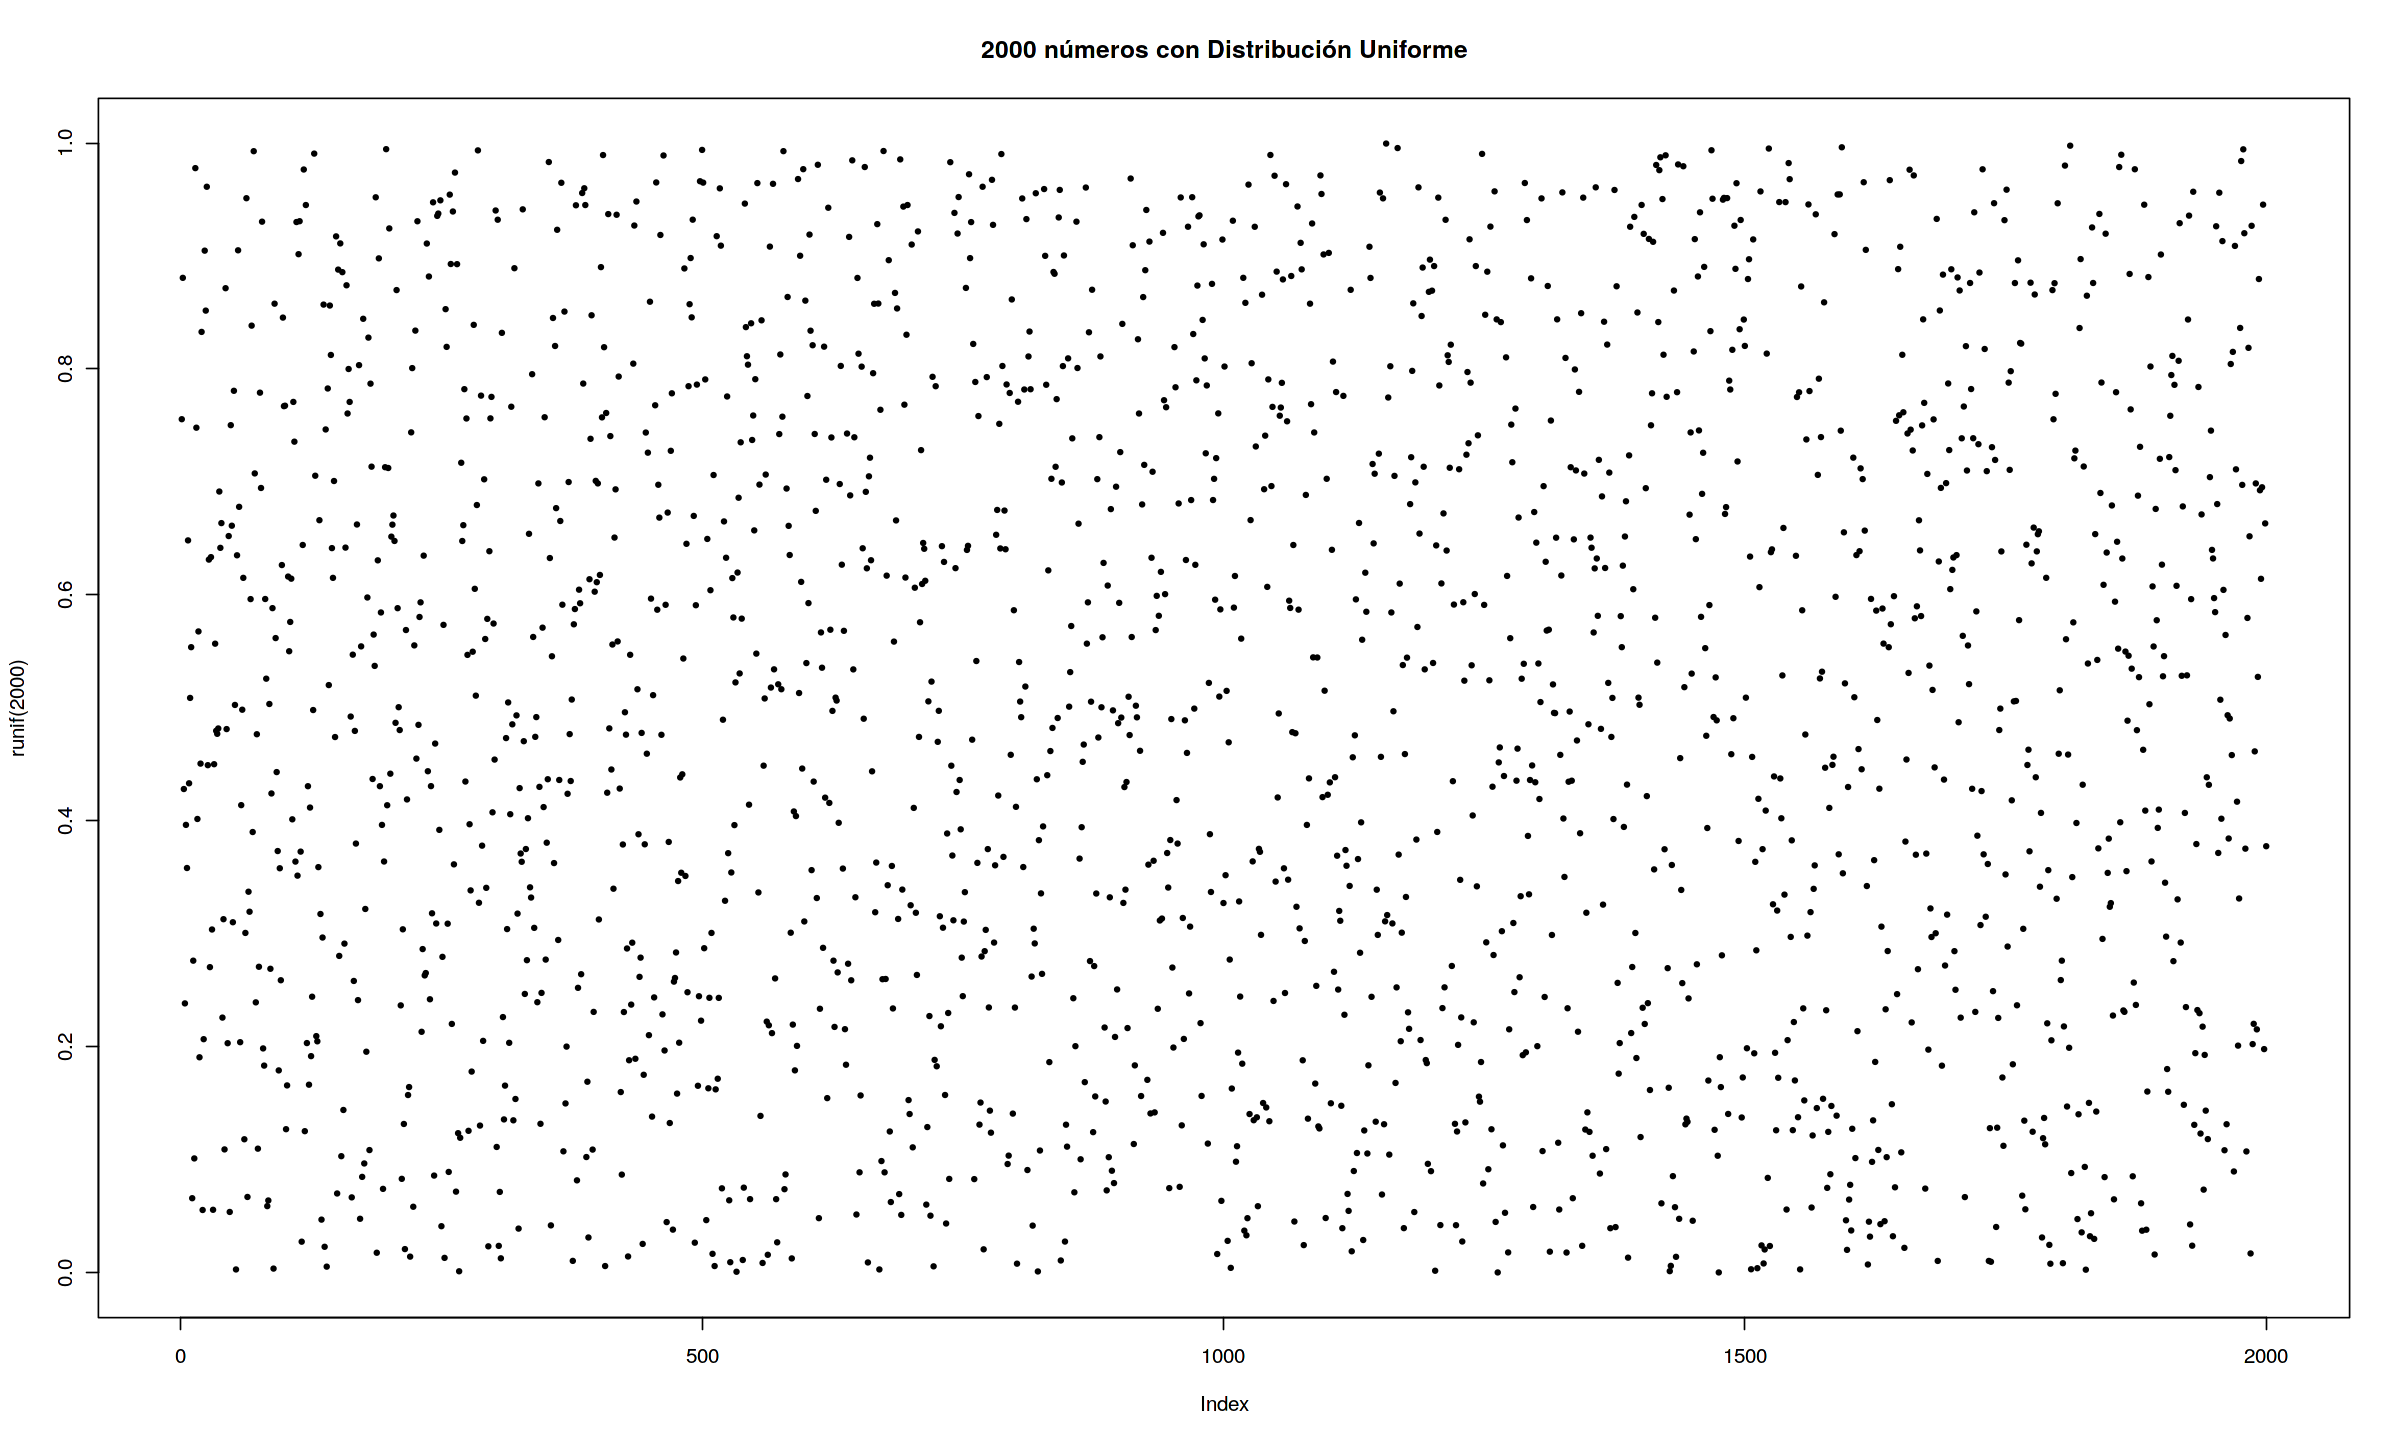

In [15]:
plot(runif(2000), pch = 16, cex = 0.6, main = "2000 números con Distribución Uniforme")

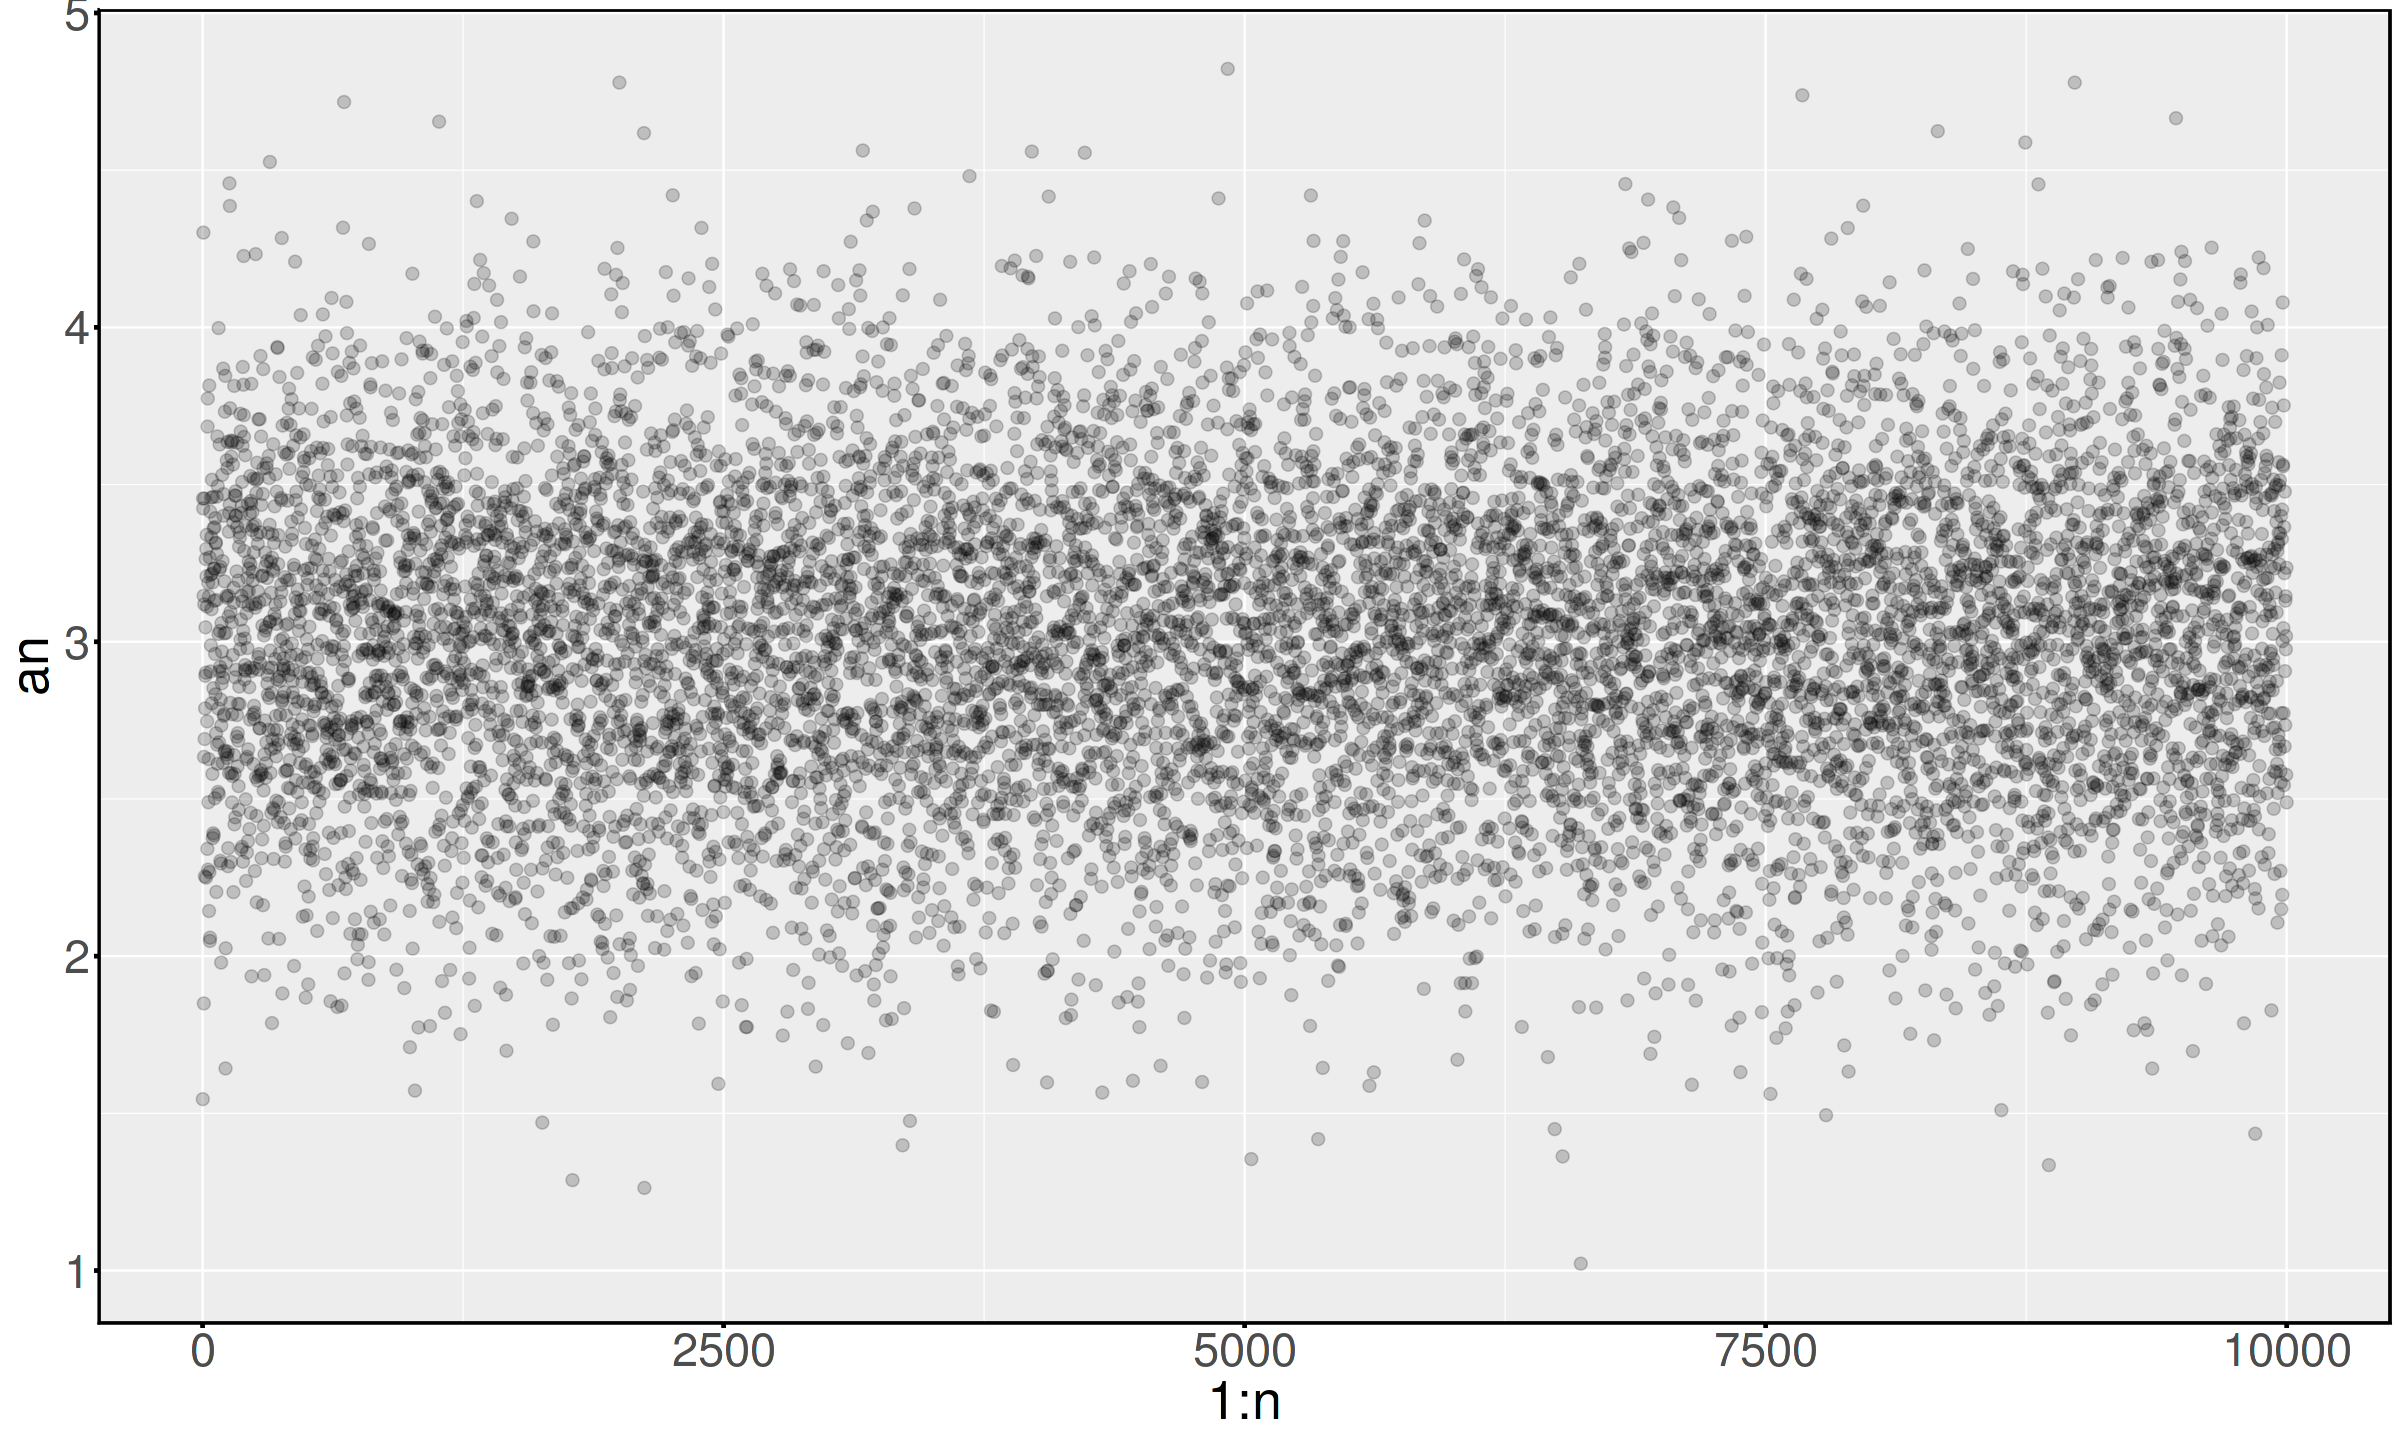

In [16]:
n <- 10000; an <- rnorm(n = n, mean = 3, sd = 0.5) ;grn <- ggplot() + geom_point(aes(x = 1:n, y = an), size = 3,alpha = 0.2) + temajuan3
show(grn)

Un histograma de lo anterior

In [17]:
mi = 3; s = 0.5;
an <- rnorm(10000, mean = mi, sd = s); x = seq(1, 5, 0.01); y <- dnorm(x = x, mean = mi, sd = s)

In [18]:
ghm <- ggplot() +   geom_histogram(aes(x = an, y = ..density..),colour = "Deepskyblue4", fill = "Deepskyblue4",alpha = 0.3, bins = nclass.FD(an)+3)  +
geom_line(aes(x = x, y = y)) +   
xlab("x") + ylab("Densidad de Probabilidad") + ggtitle("Histograma - Distribución Normal") +   temajuan3

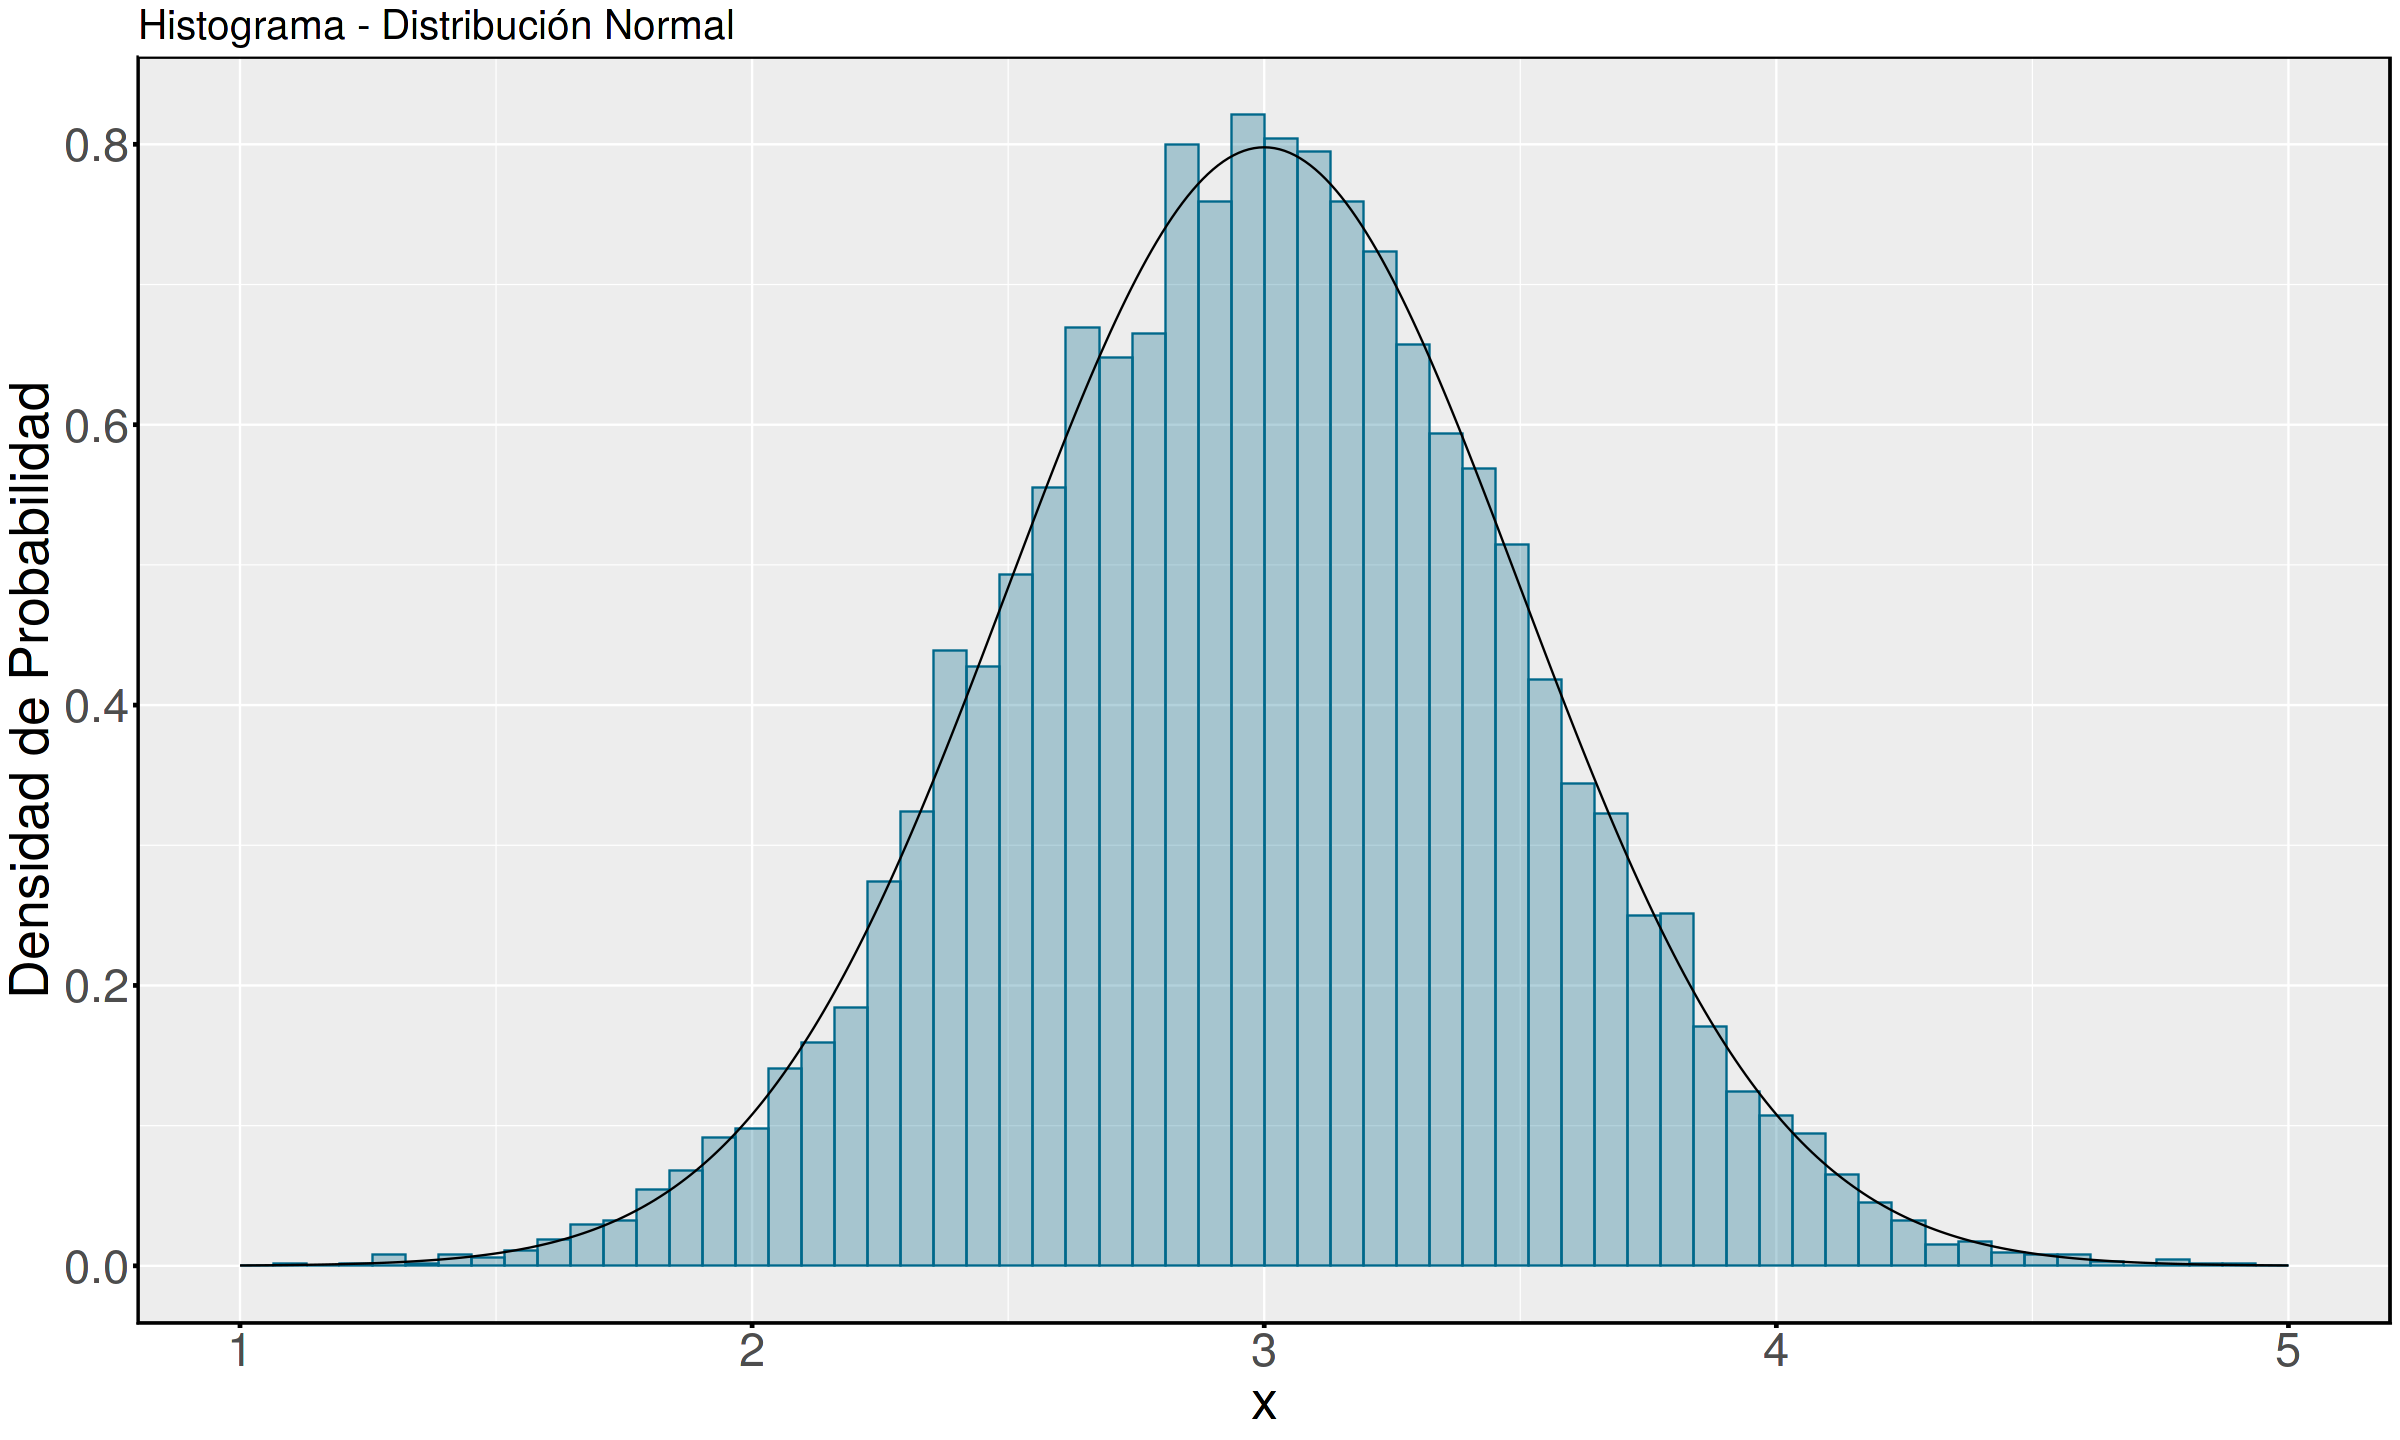

In [19]:
fig(20,12);show(ghm)

Los generadores de pseudo aleatorios sirven para muchas cosas, pero acá nos hacen ***ver*** algunos resultados y modelar las situaciones de los teoremas. Usarlos nos simplifica la vida.

(ver apunte para los comandos, jugar, probar, etc)

# TLC, MM, $\overline{x}$ y $\mu$, SEM

**Teorema del clásico sabor limón.**

Sean $X_1, X_2, X_3,.., X_N$, N variables aleatorias ***independientes e idénticamente distribuídas*** (IID), con distribuciones de probabilidad ***inespecificadas***, con media $\mu$ y varianza $\sigma^2$.

Entonces la media de la muestra $$\bar{X} =  \sum_{i = 1}^{N} X_i / N$$

tiene una distribución con media $\mu$ y varianza $\sigma^2/N$, que se aproxima a una normal a medida que $N\rightarrow \infty$

### Vamos por las $X_i$: Distribución Uniforme

* Suponemos soberanamente una distribución uniforme, entre a=4 y b = 6
* La media $\mu_X = 5$. La desviación estándar es $\sigma_X = 2/\sqrt{12} = \sqrt{3}/3 \approx 0.577$

### Vamos por la $\overline{X} = \sum_{i = 1}^{6} X_i /6$

El teorema nos dice que $\overline{X}$ tiene una distribución normal, de media $\mu = 5$ y $\sigma = \sigma_X / \sqrt(6)$

***
***
****

Todo esto se puede hacer generando pseudo aleatorios y sacando medias....vamos.

# Media Muestral y SEM

* Un generador de pseudo aleatorios nos permite tener una muestra de datos de alguna distribución.

* ***Un valor*** de la media muestral, $\overline{x}$ puede sacarse.

* Pueden sacarse 10 000 valores.

* Podemos ***ver*** el TLC.

Un valor de media muestral, con tamaño de muestra $n = 6$, sacado de una distribución uniforme, con min = 4, max = 6.

In [ ]:
medidas <- runif(n = 6, min = 4, max = 6)

In [30]:
medidas.old <- medidas; medidas

[1] 5.710139 5.875434 5.261308 5.497815 4.588579 5.572297

In [31]:
medidas[6] <- 9
mm <- mean(medidas); 
dsm <- sd(medidas);
mm
dsm
dsm/sqrt(6)

[1] 5.988879

[1] 1.541996

[1] 0.6295172

In [26]:
x <- seq(3,7, 0.001)
f1 <- dunif(x = x, min = 4, max = 6); F1 <- punif(q = x, min = 4, max = 6)

##función densidad de probabilidad uniforme
gnunif <- ggplot() + 
  geom_line(aes( x = x, y = f1) ) + 
  geom_vline(aes(xintercept =  mm), colour = "Red3", lwd = 1.5, lty = 2) + 
  scale_x_continuous(expand = c(0,0), breaks = seq(3,7,1), labels = c("3", "a = 4", TeX("$\\mu = 5$"), "b = 6", "7" ), limits = c(3,7)) +
  ylab("f(x)") + xlab("x") + temajuan3 + theme(legend.position = c(0.1,0.75))


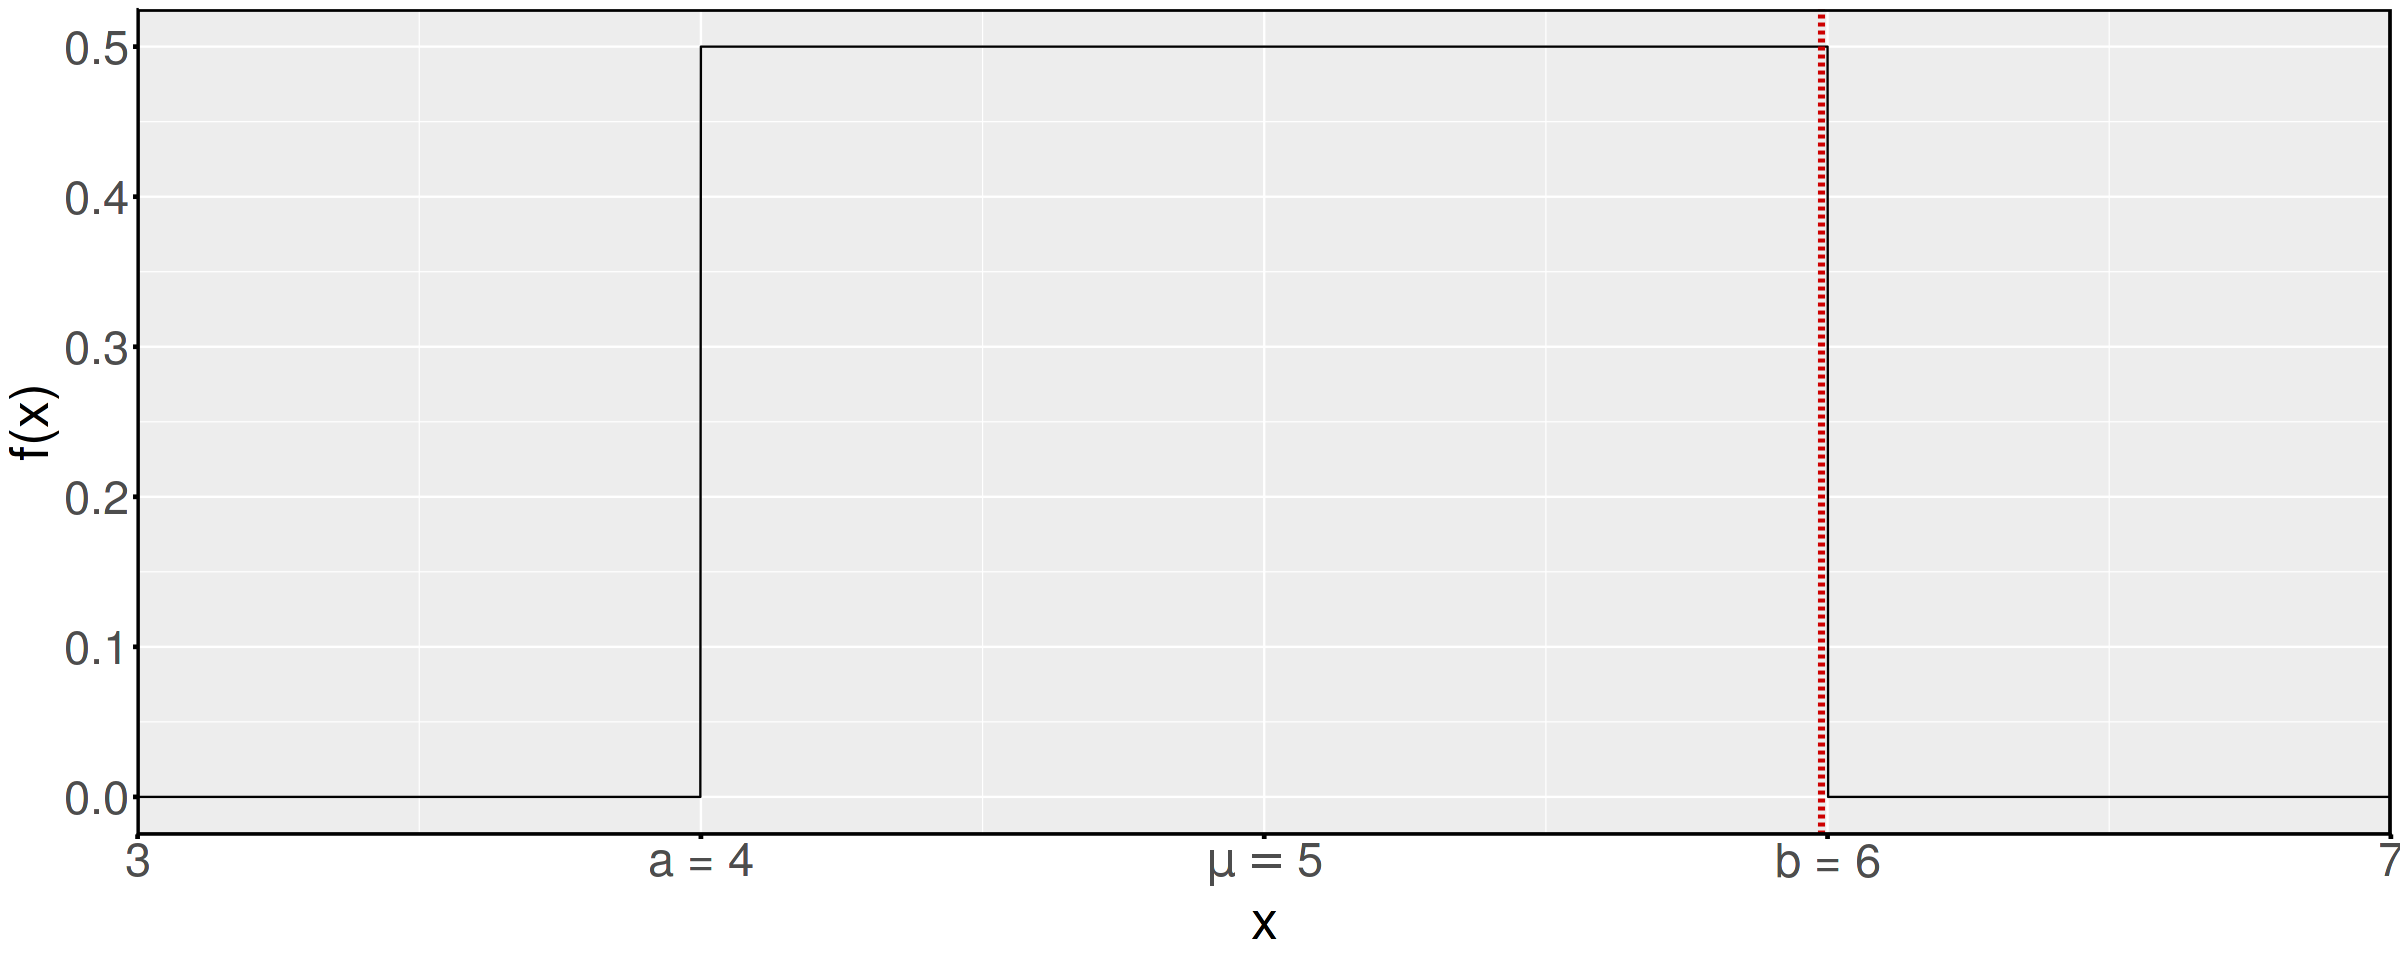

In [32]:
fig(20,8); show(gnunif)

La media muestral no le pega a la media $\mu$...como suele pasar.

pero ahora sacamos 10000 medias, cada una con $n=6$ elementos. Y vemos el histograma.

In [33]:
mmv <- vector(mode = "numeric", length = 10000)
for(i in 1:10000){mmv[i] <- mean(runif(n = 6, min = 4, max = 6))}

In [36]:
mi = 5; s = sqrt(3)/(3*sqrt(6));
x = seq(mi-3*s, mi+3*s, 0.01); y <- dnorm(x = x, mean = mi, sd = s)
ghm <- ggplot() +   geom_histogram(aes(x = mmv, y = ..density..),colour = "Deepskyblue4", fill = "Deepskyblue4",alpha = 0.3, bins = nclass.FD(an))  +
geom_line(aes(x = x, y = y)) +   
geom_vline(aes(xintercept = mm), colour = "red3", lwd = 1, lty = 2)+
xlab(TeX("$\\bar{X} = \\sum_{i = 1}{n = 6} \\frac{X_i}{6}$")) + ylab("Densidad de Probabilidad") + ggtitle("Medias muestrales de una Distribución Unifrome....distribuídas normalmente :)") +   temajuan3

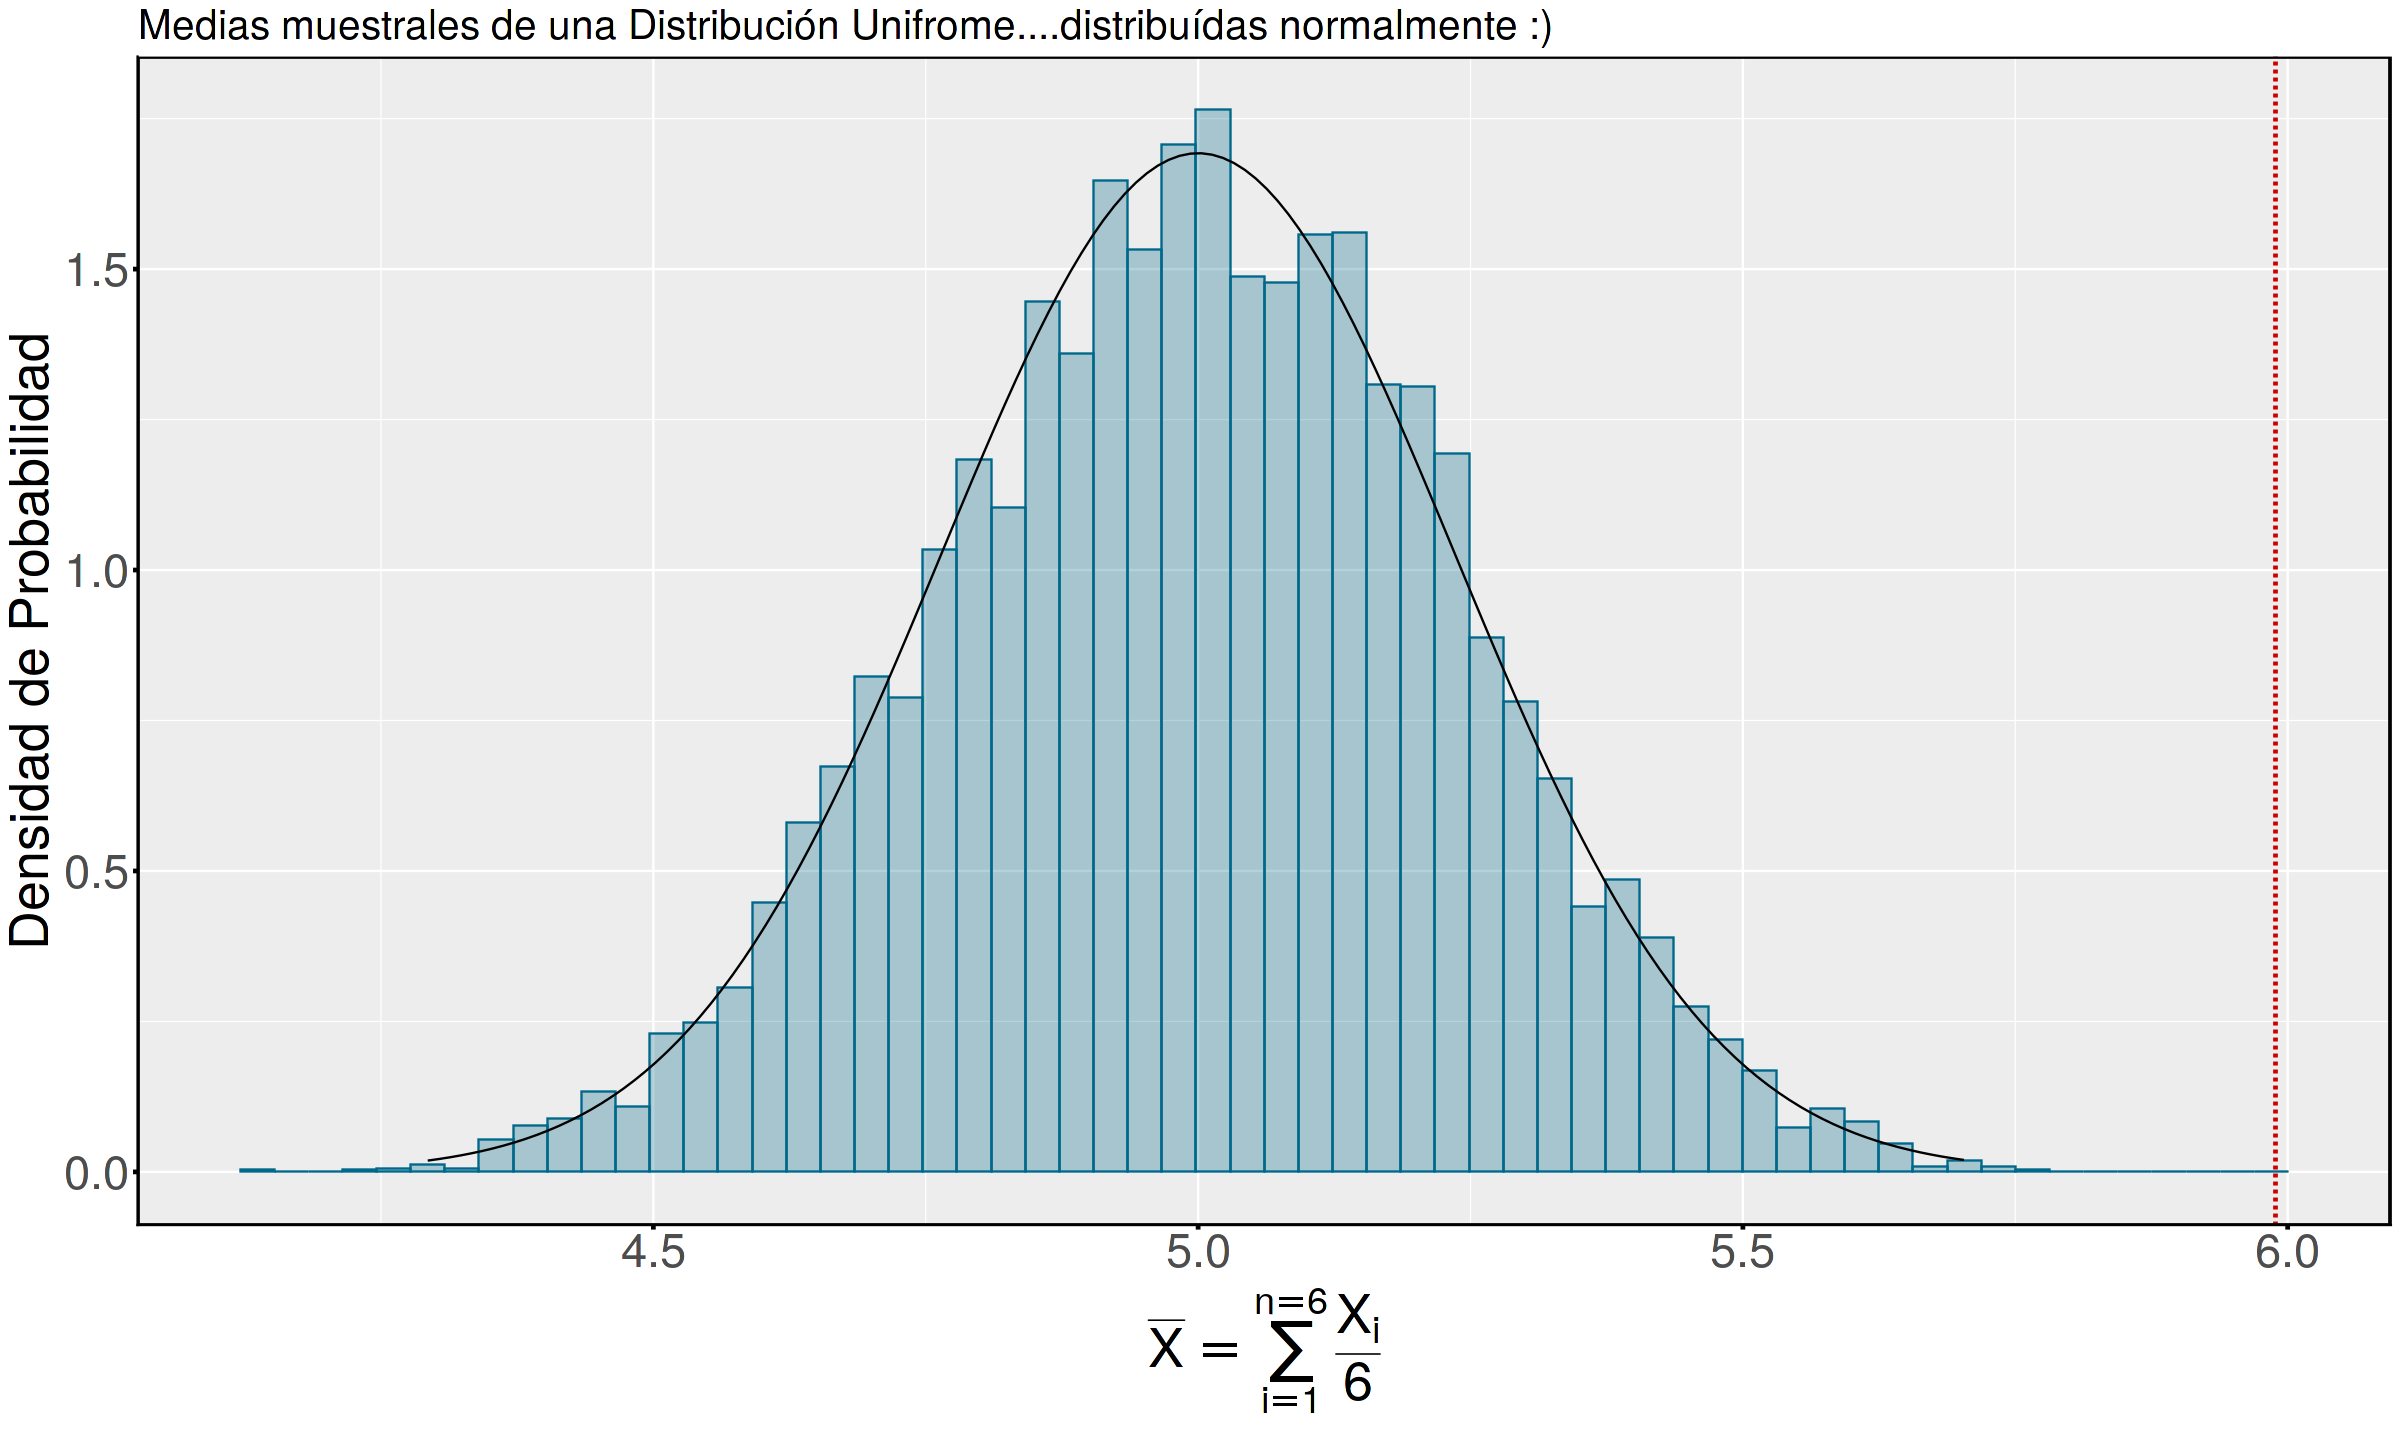

In [37]:
fig(20,12);show(ghm)

* Las medias muestrales $\overline{X}$ ***viven*** casi siempre en una distribución normal.

* Esta distribución normal tiene la media de cada $X_i$, y tiene una $\sigma =\sigma_X / \sqrt{n}$, donde $n$ es la cantidad de elementos que fueron dentro de la media.

* Aumentando $n$ la gaussiana se ***hace más picuda***.

* Cuando tenemos sólo un valor de media muestral $\overline{x}$, le decimos, a lo ***macho***(ayyy)

    + ***Sabemos donde viví' vó' eh.***
    
    + ***Te vamo a í' a buscar.***

# SEM, ESM, coso: Error estándar de la media (muestral)

La idea de ESM es una idea que sale del TLC. Es ***simple*** (y lo tenemos que aprender de pe a pa)

* A una media muestral $\overline{x}$ le asignamos el $\sigma$ de la distribución normal (que tiene la media teórica de la distribución de donde salimos).

* Entonces $\overline{x} \pm \; \sigma$ va a contener a $\mu$ con 68.3% de probabilidades.
* Entonces $\overline{x} \pm 2\sigma$ va a contener a $\mu$ con 95.4% de probabilidades.
* Entonces $\overline{x} \pm 3\sigma$ va a contener a $\mu$ con 99.7% de probabilidades.


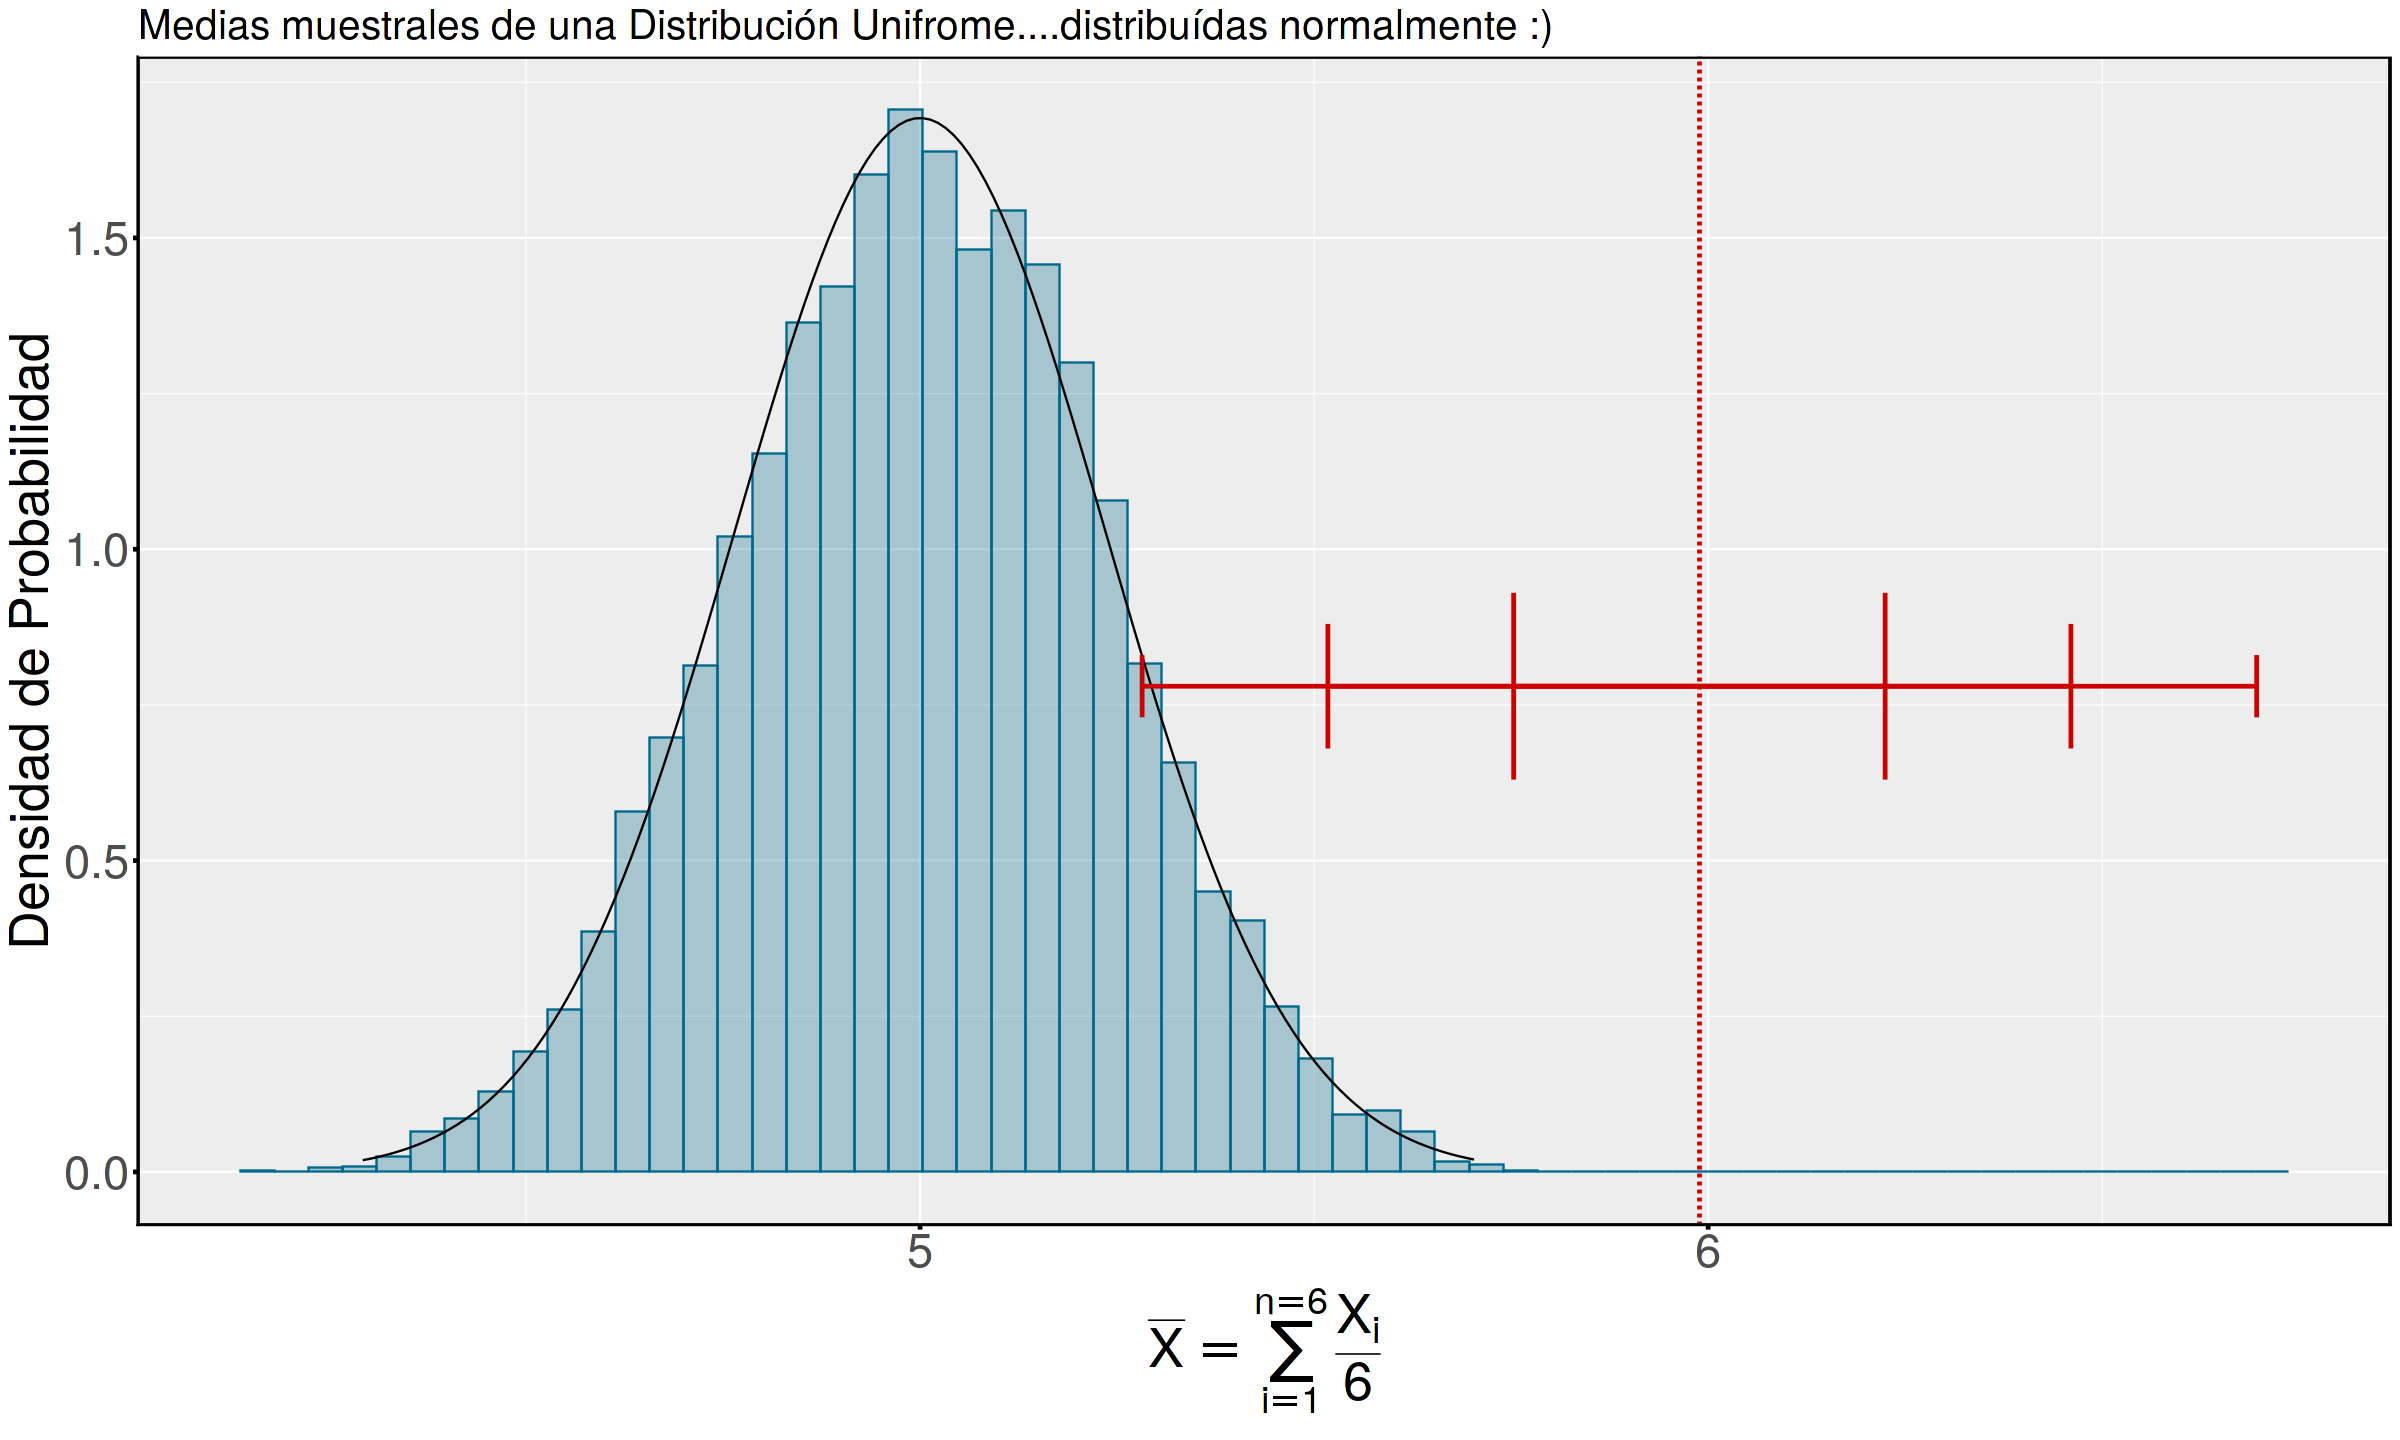

In [38]:
sigma <- sqrt(3)/(3*sqrt(6))
ghme <- ghm +   geom_errorbarh(aes(xmax = mm + c(1:3)* sigma, xmin = mm - c(1:3)* sigma, y = 0.78,height = c(.3,.2,.1)), lwd = 1, colour = "red3")
show(ghme)

Entonces: 
* Si hacemos $n = 6$ medidas de una cantidad y obtenemos:

In [50]:
medidas;cat(bold("La media muestral es mm =",mean(medidas)), "\n");cat(bold("la desviación estándar de la muestra es sd = ", sd(medidas)));cat("\n \n");cat(bold(red("Entonces la media verdadera está en una distribución normal,
que tiene una desviación estándar sigma =", sd(medidas)/sqrt(length(medidas)) )));cat("\n \n")
cat(bold(blue("Y el valor que calculamos de  media muestralmm = ", mm, "contendrá 
a la media verdadera = ", 5, "si le agregamos incertezas de 1, 2,3,4,5 desviaciones
estándar de la distribución normal donde vive"   )))

[1] 5.508808 4.865199 5.556846 5.955147 4.505637 5.913671

La media muestral es mm = 5.38421783549711 
la desviación estándar de la muestra es sd =  0.581874303506268
 
Entonces la media verdadera está en una distribución normal,
que tiene una desviación estándar sigma = 0.237549189671285
 
Y el valor que calculamos de  media muestralmm =  5.38421783549711 contendrá 
a la media verdadera =  5 si le agregamos incertezas de 1, 2,3,4,5 desviaciones
estándar de la distribución normal donde vive

Bueno, ya podemos calcular errores en la media y ver qué pasa.